# Quantum Tilted Loss

Simulations of QAOA, comparison with CVaR.
https://arxiv.org/pdf/1907.04769

In [5]:
from qiskit.circuit.library import real_amplitudes
from scipy import optimize
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.primitives import StatevectorEstimator as Estimator

from qiskit_algorithms import QAOA, NumPyEigensolver
from qiskit_finance.applications.optimization.portfolio_optimization import PortfolioOptimization
from qiskit_optimization.converters import LinearEqualityToPenalty
from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# prepare problem instance
n = 6  # number of assets
q = 0.5 # risk factor
budget = n // 2  # budget
penalty = 12  # penalty factor for equality constraints

sampler = Sampler()
estimator = Estimator()


In [7]:
# instance from paper
mu = np.array([0.7313, 0.9893, 0.2725, 0.8750, 0.7667, 0.3622])
sigma = np.array([
    [ 0.7312, -0.6233,  0.4689, -0.5452, -0.0082, -0.3809],
    [-0.6233,  2.4732, -0.7538,  2.4659, -0.0733,  0.8945],
    [ 0.4689, -0.7538,  1.1543, -1.4095,  0.0007, -0.4301],
    [-0.5452,  2.4659, -1.4095,  3.5067,  0.2012,  1.0922],
    [-0.0082, -0.0733,  0.0007,  0.2012,  0.6231,  0.1509],
    [-0.3809,  0.8945, -0.4301,  1.0922,  0.1509,  0.8992]
])

# or random instance
# mu, sigma = portfolio.random_model(n, seed=123)  # expected returns and covariance matrix

In [8]:
converter = LinearEqualityToPenalty(penalty=penalty)
problem = PortfolioOptimization(mu, sigma, q, budget).to_quadratic_program()
H, offset = converter.convert(problem).to_ising()

es = NumPyEigensolver()
result = es.compute_eigenvalues(H)
optimal_value = (np.real(result.eigenvalues) + offset).item()
print('optimal_value = %.4f' % optimal_value)

optimal_value = -1.2783


# Variational quantum algorithms

In [22]:
# set classical optimizer
maxiter = 30

# set variational ansatz
#var_form = RY(n, depth=1)
var_form = real_amplitudes(n, reps=1)
# var_form = QAOAVarForm(H, 1)  # use this ansatz for CVaR-QAOA
m = var_form.num_parameters

# set backend
simulator = AerSimulator(method='statevector') # Uses 'automatic' method by default

In [10]:
# They use cvar
def compute_cvar(probabilities, values, alpha):
    """
    Auxilliary method to computes CVaR for given probabilities, values, and confidence level.

    Attributes:
    - probabilities: list/array of probabilities
    - values: list/array of corresponding values
    - alpha: confidence level

    Returns:
    - CVaR
    """
    sorted_indices = np.argsort(values)
    probs = np.array(probabilities)[sorted_indices]
    vals = np.array(values)[sorted_indices]
    cvar = 0
    total_prob = 0
    for i, (p, v) in enumerate(zip(probs, vals)):
        done = False
        if p >= alpha - total_prob:
            p = alpha - total_prob
            done = True
        total_prob += p
        cvar += p * v
    cvar /= total_prob
    return cvar

In [11]:

def compute_tilted_loss(probabilities, values):
    """
    Auxilliary method to computes tilted loss for given probabilities, values, and confidence level.

    Attributes:
    - probabilities: list/array of probabilities
    - values: list/array of corresponding values
    - alpha: confidence level

    Returns:
    - CVaR
    """
    sorted_indices = np.argsort(values)
    probs = np.array(probabilities)[sorted_indices]
    vals = np.array(values)[sorted_indices]

    tilted_loss = 0
    for i, (p, v) in enumerate(zip(probs, vals)):
        tilted_loss += np.exp(- p * v)
    tilted_loss = np.log(tilted_loss / len(probabilities))
    return tilted_loss

In [12]:
def eval_bitstring(H, x):
    """
    Auxilliary method to evaluate the objective function for a given bitstring

    Attributes:
    - H: cost Hamiltonian
    - x: bitstring

    Returns:
    - objective value
    """

    # invert bitstring for convenience and translate to +/-1
    x = x[::-1]
    spins = np.array([(-1)**(b == '1') for b in x])
    value = 0

    # loop over pauli terms and add contribution to objective
    for i, p in enumerate(H.coeffs):
         weight = np.real(p)
         indices = np.where(H.paulis.z[i])
         value += weight * np.prod(spins[indices])

    return value

In [20]:
class Objective:
    """
    Wrapper for objective function to track the history of evaluations
    """

    def __init__(self, var_form, H, offset, alpha, optimal=None):
        self.history_cvar = []
        self.history_tilted_loss = []

        self.var_form = var_form
        self.H = H
        self.offset = offset
        self.alpha = alpha
        self.optimal = optimal
        self.opt_history = []

    def evaluate_cvar(self, thetas):

        # create and run circuit
        qc = self.var_form.assign_parameters(thetas)
        qc.measure_all()

        # 2. Instantiate the AerSimulator
        job = sampler.run([qc], shots=None)
        result = job.result()
        counts = result[0].data.meas.get_counts()
        # evaluate counts
        probabilities = np.zeros(len(counts))
        values = np.zeros(len(counts))
        for i, (x, p) in enumerate(counts.items()):
            values[i] = eval_bitstring(self.H, x) + self.offset
            probabilities[i] = p

        # track optimal probability
        if self.optimal:
            indices = np.where(values <= self.optimal + 1e-8)
            self.opt_history += [sum(probabilities[indices])]

        # evaluate cvar
        cvar = compute_cvar(probabilities, values, self.alpha)
        self.history_cvar += [cvar]
        return cvar

    def evaluate_tilted_loss(self, thetas):

        # create and run circuit
        qc = self.var_form.assign_parameters(thetas)
        qc.measure_all()

        # 2. Instantiate the AerSimulator
        job = sampler.run([qc], shots=None)
        result = job.result()
        counts = result[0].data.meas.get_counts()
        # evaluate counts
        probabilities = np.zeros(len(counts))
        values = np.zeros(len(counts))
        for i, (x, p) in enumerate(counts.items()):
            values[i] = eval_bitstring(self.H, x) + self.offset
            probabilities[i] = p

        # track optimal probability
        if self.optimal:
            indices = np.where(values <= self.optimal + 1e-8)
            self.opt_history += [sum(probabilities[indices])]

        # evaluate tilted loss
        tilted_loss = compute_tilted_loss(probabilities, values)
        self.history_tilted_loss += [tilted_loss]
        return tilted_loss

In [23]:
# CVaR
# run variational optimization for different values of alpha
alphas = [1.0, 0.25, 0.10]  # confidence levels to be evaluated

initial_point = np.random.rand(m)  # same random initial set of parameters for all experiments
objectives_cvar = {}  # set of tested objective functions w.r.t. alpha
for alpha in alphas:
    objectives_cvar[alpha] = Objective(var_form, H, offset, alpha, optimal=optimal_value)
    optimize.minimize(objectives_cvar[alpha].evaluate_cvar, initial_point, method='COBYLA')

# tilted loss
alphas = [1.0, 0.25, 0.10]  # confidence levels to be evaluated
initial_point = np.random.rand(m)  # same random initial set of parameters for all experiments
objectives_tilted_loss = {}  # set of tested objective functions w.r.t. alpha
for alpha in alphas:
    objectives_tilted_loss[alpha] = Objective(var_form, H, offset, alpha, optimal=optimal_value)
    optimize.minimize(objectives_tilted_loss[alpha].evaluate_tilted_loss, initial_point, method='COBYLA')

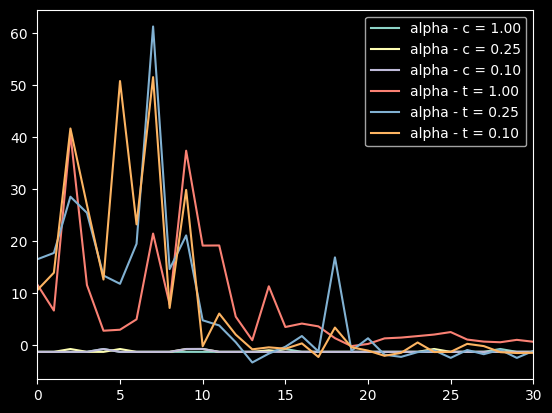

In [25]:
# plot resulting history of objective values
for alpha in alphas:
    plt.plot(objectives_cvar[alpha].history_cvar, label='alpha - c = %.2f' % alpha)
for alpha in alphas:
    plt.plot(objectives_tilted_loss[alpha].history_tilted_loss, label='alpha - t = %.2f' % alpha)
plt.legend()
plt.xlim(0, maxiter)
plt.show()

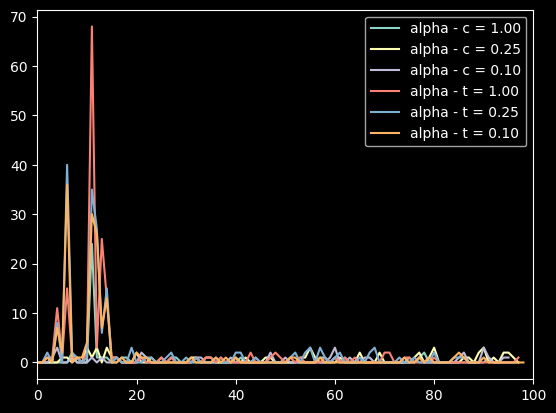

In [16]:
# plot
for alpha in alphas:
    history = objectives_cvar[alpha].opt_history  # get history for alpha
    plt.plot(history, label='alpha - c = %.2f' % alpha)  # plot history for alpha
for alpha in alphas:
    history = objectives_tilted_loss[alpha].opt_history  # get history for alpha
    plt.plot(history, label='alpha - t = %.2f' % alpha)  # plot history for alpha
plt.legend()
plt.xlim(0, maxiter)
plt.show()

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   -----------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Classical machine learning paper
https://arxiv.org/pdf/2109.06141

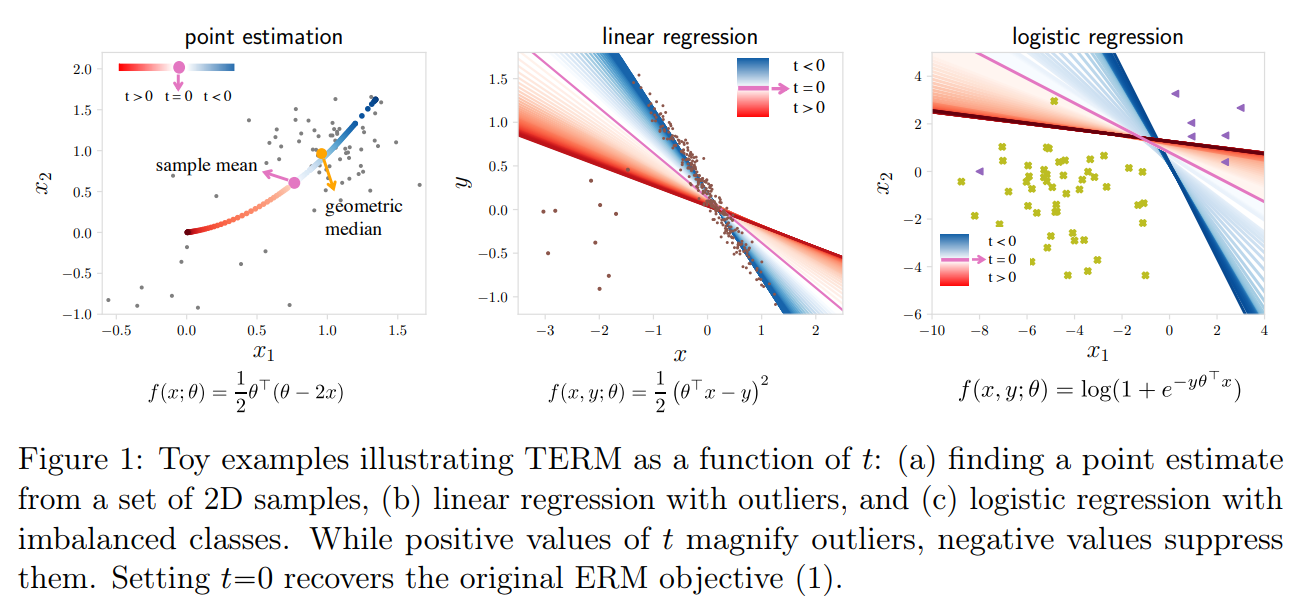

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def abline(a, b, label_, c=None):

    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = a * x_vals + b
    plt.plot(x_vals, y_vals, label=label_, color=c, zorder=1)




ModuleNotFoundError: No module named 'matplotlib'

In [1]:
num_sample = 290
num_outlier = 10
total_samples = num_sample + num_outlier

theta = [-1, 0.2]
#X = np.random.random_sample(num_sample) * 0.5
X = np.random.normal(0, 0.5, num_sample)
y = theta[0]*X + theta[1]

y += np.random.normal(0, 0.1, num_sample)

X_out = np.random.normal(-2, 0.5, num_outlier)
y_out = np.random.normal(0, 0.5, num_outlier)


plt.figure(figsize=(8, 8))
plt.scatter(X, y, s=2, label='the major cluster of data')
plt.scatter(X_out, y_out, s=2, label="outliers")
abline(theta[0], theta[1], 'ground truth', "red")
plt.legend()

y = np.append(y, y_out)
X = np.append(X, X_out)

print(X.shape, y.shape)

Hello


In [ ]:
iters = 20000

X = X.reshape((total_samples, 1))
intercept = np.ones((X.shape[0], 1))
X_concatenate = np.concatenate((X, intercept), axis=1)


thetas=[]
max_=[]
min_=[]
avg_=[]
var_=[]
ts=[]

for t in np.arange(-10, 0, 0.2):
    theta_hat = np.zeros(2)
    for _ in range(iters):
        y_pred = np.dot(X_concatenate, theta_hat)
        error = (y-y_pred)**2
        grad = np.dot(-1*X_concatenate.T, np.multiply(np.exp(t*error), 2 * (y-y_pred)))
        loss_mean = np.sum(np.exp(t * error))
        theta_hat = theta_hat - 0.01 * grad/loss_mean

    thetas.append([theta_hat[0], theta_hat[1]])
    print(theta_hat)

    loss = error * 0.5
    ts.append(t)
    avg_.append(np.mean(loss))
    max_.append(max(loss))
    min_.append(min(loss))
    var_.append(np.var(loss))

    print("t={}, max loss: {}, min loss: {}, avg loss: {}, variance: {}".format(t, max(loss), min(loss), np.mean(loss), np.var(loss)))

for t in np.arange(0, 10, 0.2):
    theta_hat = np.zeros(2)
    for _ in range(iters):
        y_pred = np.dot(X_concatenate, theta_hat)
        error = (y-y_pred)**2
        grad = np.dot(-1*X_concatenate.T, np.multiply(np.exp(t*error), 2 * (y-y_pred)))
        loss_mean = np.sum(np.exp(t * error))
        theta_hat = theta_hat - 0.01 * grad/loss_mean

    thetas.append([theta_hat[0], theta_hat[1]])
    print(theta_hat)

    loss = error * 0.5
    ts.append(t)
    avg_.append(np.mean(loss))
    max_.append(max(loss))
    min_.append(min(loss))
    var_.append(np.var(loss))

    print("t={}, max loss: {}, min loss: {}, avg loss: {}, variance: {}".format(t, max(loss), min(loss), np.mean(loss), np.var(loss)))

In [ ]:
import matplotlib.pylab as pl
from matplotlib import rc
rc('text', usetex=True)

colors_positive = pl.cm.Reds(np.linspace(0,0.8, 50))
colors_negative = pl.cm.Blues(np.linspace(0, 0.8, 50))

plt.figure(figsize=(4, 3.5))


ax = plt.subplot(1, 1, 1)



print(len(thetas))
for i in range(len(thetas)):
    if i > 50:
        abline(thetas[i][0], thetas[i][1], None, c=colors_positive[min(int((i-50)*1.1), 39)])
    elif i < 50:
        abline(thetas[i][0], thetas[i][1], None, c=colors_negative[min(int((49-i)*3.2), 49)])


plt.scatter(X, y, s=1, c='#8c564b', zorder=2)
plt.scatter(X_out, y_out, s=3,  c='#8c564b', zorder=2)
abline(thetas[50][0], thetas[50][1], None, c='#e377c2')




ax.tick_params(color='#dddddd')
ax.spines['bottom'].set_color('#dddddd')
ax.spines['top'].set_color('#dddddd')
ax.spines['right'].set_color('#dddddd')
ax.spines['left'].set_color('#dddddd')

plt.xlim(-3.5, 2.5)
plt.ylim(-1.2, 1.8)
plt.title("linear regression", fontsize=17)
plt.xlabel(r'$x$', fontsize=17)
plt.ylabel(r'$y$', fontsize=17)
plt.tight_layout()